# Setup & Load

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.width", 200)

PROJECT_ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data" / "raw").exists()
)
ENRICHED = PROJECT_ROOT / "data" / "processed" / "london_enriched_2026-09-22.csv"

# Chart colours: one calm blue for bars, grey ink for text and reference lines
BAR = "#2a78d6"
INK = "#52514e"
MUTED = "#898781"
GRID = "#e1e0d9"

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": GRID, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": INK, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
})

df = pd.read_csv(ENRICHED, low_memory=False)
print(f"Loaded {len(df):,} businesses")

Loaded 81,572 businesses


# Build the Target

In [3]:
rated = df[df["RatingValue"].isin(["0", "1", "2", "3", "4", "5"])].copy()
rated["rating"] = rated["RatingValue"].astype(int)
rated["fail"] = (rated["rating"] <= 2).astype(int)

BASE_RATE = rated["fail"].mean()
print(f"Rated businesses: {len(rated):,}")
print(f"Failures:         {rated['fail'].sum():,}")
print(f"Base fail rate:   {BASE_RATE:.1%}")

Rated businesses: 71,390
Failures:         4,005
Base fail rate:   5.6%


# Question 1, fail rate by business type

                                       businesses  failures fail_rate
BusinessType                                                         
Retailers - other                           13586      1238      9.1%
Takeaway/sandwich shop                       8565       669      7.8%
Restaurant/Cafe/Canteen                     25288      1503      5.9%
Manufacturers/packers                         856        44      5.1%
Importers/Exporters                           124         5      4.0%
Distributors/Transporters                     433        17      3.9%
Pub/bar/nightclub                            3717       140      3.8%
Mobile caterer                               1949        63      3.2%
Retailers - supermarkets/hypermarkets        2260        58      2.6%
Hotel/bed & breakfast/guest house             939        23      2.4%
Other catering premises                      6100       135      2.2%
Caring Premises                              4325        82      1.9%
School/college/unive

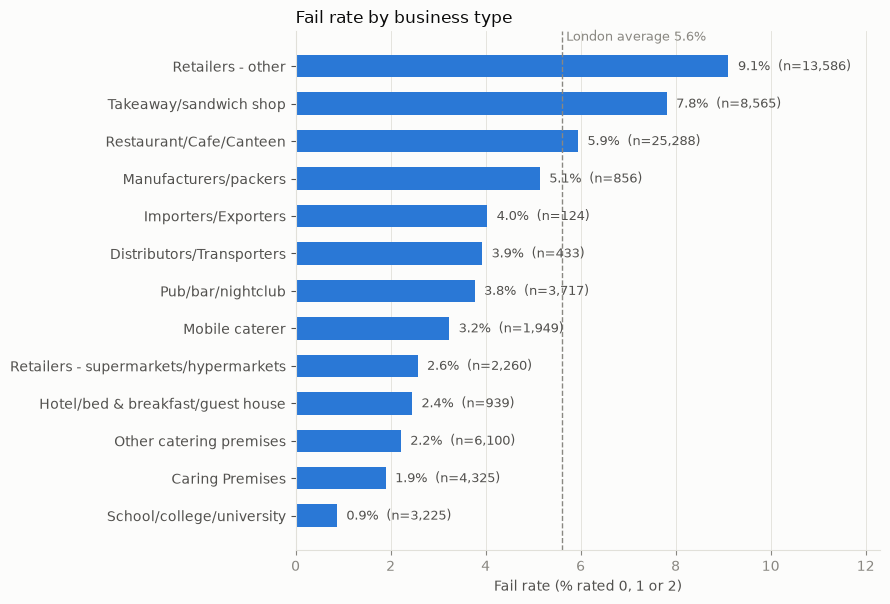

In [4]:
def fail_rate_table(data, column, min_businesses=50):
    """Fail rate per group, with group size. Small groups are dropped as unreliable."""
    table = (
        data.groupby(column)["fail"]
        .agg(businesses="size", failures="sum", fail_rate="mean")
        .query("businesses >= @min_businesses")
        .sort_values("fail_rate", ascending=False)
    )
    return table


def plot_fail_rate(table, title):
    """Horizontal bars of fail rate per group, highest at the top, with the overall rate marked."""
    table = table.sort_values("fail_rate")
    fig, ax = plt.subplots(figsize=(9, 0.38 * len(table) + 1.2))

    ax.barh(table.index, table["fail_rate"] * 100, color=BAR, height=0.6)
    ax.axvline(BASE_RATE * 100, color=MUTED, linestyle="--", linewidth=1)
    ax.text(BASE_RATE * 100, len(table) - 0.4, f" London average {BASE_RATE:.1%}",
            color=MUTED, fontsize=9, va="bottom")

    for y, (rate, n) in enumerate(zip(table["fail_rate"], table["businesses"])):
        ax.text(rate * 100 + 0.2, y, f"{rate:.1%}  (n={n:,})", va="center", fontsize=9)

    ax.set_xlabel("Fail rate (% rated 0, 1 or 2)")
    ax.set_title(title, loc="left", fontsize=12, color="#0b0b0b")
    ax.grid(axis="x", color=GRID, linewidth=0.6)
    ax.set_axisbelow(True)
    ax.set_xlim(0, table["fail_rate"].max() * 100 * 1.35)
    plt.tight_layout()
    plt.show()


by_type = fail_rate_table(rated, "BusinessType")
print(by_type.to_string(formatters={"fail_rate": "{:.1%}".format}))
plot_fail_rate(by_type, "Fail rate by business type")

## Q1: Fail rate by business type: findings

- **Base rate:** 71,390 rated businesses, 4,005 failures (**5.6%**). This matches the raw
  data exactly, so the enrichment join did not lose or duplicate any businesses.
- **Huge spread (about 10x):** from **9.1%** (Retailers - other) down to **0.9%** (schools).
  Business type on its own is a strong signal.
- **Highest rate is not restaurants but "Retailers - other" (9.1%)**: small shops such as
  convenience stores, grocers, off-licences, butchers and bakers. Likely reasons: fresh or
  chilled food, limited space and staff, no dedicated food safety manager.
- **Three types produce 85% of all failures:**
  - Restaurant/Cafe/Canteen: 1,503 failures (37.5%), average rate (5.9%) but very high volume
  - Retailers - other: 1,238 failures (30.9%)
  - Takeaway/sandwich shop: 669 failures (16.7%)
- **Rate vs volume tell different stories:** restaurants have an average rate but the most
  failures in total. Inspectors care about both.
- **Institutional premises rarely fail:** schools 0.9%, caring premises 1.9%,
  supermarkets 2.6%. Formal procedures, trained staff and head-office audits likely help.
  Supermarkets hint that chains may fail less than independents (to check in Q6).
- **Mobile caterers are low (3.2%)**, consistent with the earlier finding that
  withheld-address / home-based businesses are low risk.

### Ideas for modelling
- **Baseline to beat:** rank every business by its business type's fail rate. The real
  model must beat this, not just random guessing.
- **Feature idea:** "Retailers - other" is a large mixed group (13,586 businesses).
  Keywords in `BusinessName` (butcher, grocer, off licence, food centre...) could split it
  into more useful subgroups.

Question 2: Fail rate by borough

                            businesses  failures fail_rate
LocalAuthorityName                                        
Newham                            2435       345     14.2%
Ealing                            3138       408     13.0%
Waltham Forest                    1858       227     12.2%
Enfield                           2138       206      9.6%
Barking and Dagenham              1229       101      8.2%
Hillingdon                        2013       163      8.1%
Camden                            3348       259      7.7%
Redbridge                         1816       128      7.0%
Lambeth                           2426       154      6.3%
Westminster                       5296       333      6.3%
Harrow                            1565        92      5.9%
Islington                         2408       138      5.7%
Barnet                            2379       131      5.5%
Tower Hamlets                     2891       158      5.5%
Brent                             2215       113      5.

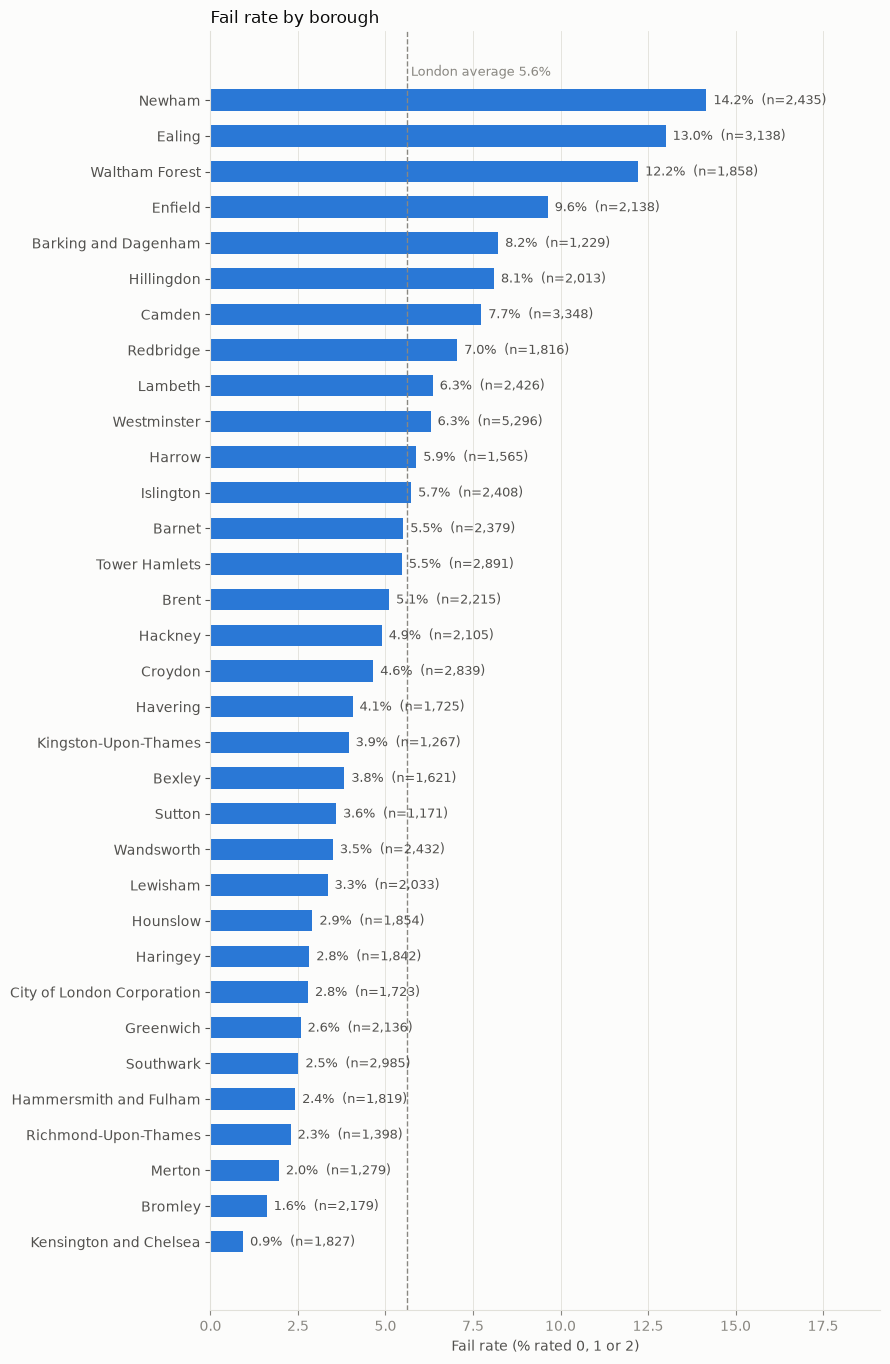

In [5]:
by_borough = fail_rate_table(rated, "LocalAuthorityName")
print(by_borough.to_string(formatters={"fail_rate": "{:.1%}".format}))
plot_fail_rate(by_borough, "Fail rate by borough")

In [6]:
# Expected fail rate for each business = London-wide fail rate of its business type
check = rated[["LocalAuthorityName", "BusinessType", "fail"]].copy()
check["expected"] = check.groupby("BusinessType")["fail"].transform("mean")

mix_adjusted = check.groupby("LocalAuthorityName").agg(
    businesses=("fail", "size"),
    actual=("fail", "mean"),
    expected=("expected", "mean"),
)
mix_adjusted["ratio"] = mix_adjusted["actual"] / mix_adjusted["expected"]
mix_adjusted = mix_adjusted.sort_values("ratio", ascending=False)

print(mix_adjusted.to_string(formatters={
    "actual": "{:.1%}".format, "expected": "{:.1%}".format, "ratio": "{:.2f}".format,
}))
print(f"\nRatio range: {mix_adjusted['ratio'].min():.2f} to {mix_adjusted['ratio'].max():.2f}")

                            businesses actual expected ratio
LocalAuthorityName                                          
Ealing                            3138  13.0%     5.3%  2.46
Newham                            2435  14.2%     5.9%  2.41
Waltham Forest                    1858  12.2%     6.2%  1.97
Enfield                           2138   9.6%     5.4%  1.78
Hillingdon                        2013   8.1%     5.7%  1.42
Barking and Dagenham              1229   8.2%     6.0%  1.37
Camden                            3348   7.7%     6.1%  1.27
Redbridge                         1816   7.0%     5.9%  1.19
Lambeth                           2426   6.3%     5.4%  1.17
Barnet                            2379   5.5%     5.0%  1.10
Westminster                       5296   6.3%     5.8%  1.08
Harrow                            1565   5.9%     5.5%  1.06
Islington                         2408   5.7%     5.6%  1.03
Brent                             2215   5.1%     5.2%  0.98
Tower Hamlets           

## Q2: Fail rate by borough: findings

- **Raw fail rates vary 16x between boroughs:** from 14.2% (Newham) to 0.9%
  (Kensington and Chelsea).
- **Business mix explains almost none of this.** Using indirect standardisation
  (expected rate = London-wide rate of each business's type, averaged per borough),
  every borough's expected rate is 5.0% to 6.2%. London boroughs have very similar
  business mixes.
- **After adjusting for mix, the gap remains 15x:** actual/expected ratio ranges from
  **2.46 (Ealing)** to **0.16 (Kensington and Chelsea)**.
- **Partly deprivation, but not only:** deprived Newham, Waltham Forest and Barking
  are high, and affluent Kensington, Richmond and Bromley are low. But deprived
  Hackney/Tower Hamlets are about average, Southwark/Haringey/Lewisham are low, and
  middling Ealing is highest. A large part likely reflects **council practice**
  (inspection strictness, targeting of visits, re-inspection frequency). The data
  cannot prove the cause.

### Design decisions
- **Evaluate within each borough:** the real user is one council ranking its own
  businesses. Main metric: recall of failures in the top 20% of each borough's list,
  averaged across boroughs. This also cancels out differences in council strictness.
- **Borough feature:** kept so the model can adjust for council differences, but
  rankings are only ever made within a borough (a London-wide ranking would just
  send inspectors to the strictest councils).
- **Confounding warning for Q3:** the strictest councils are also deprived, so
  deprivation must be checked both across London and within boroughs.

Question 3: Deprivation and density

Across London (national IMD decile, 1 = most deprived):
            businesses fail_rate
imd_decile                      
1                 2732     10.6%
2                 9358      9.1%
3                11406      8.0%
4                10822      6.2%
5                 7119      5.4%
6                 5618      4.2%
7                 5713      3.8%
8                 6210      3.1%
9                 2730      3.2%
10                1305      1.8%

Within boroughs (quintile of the borough's own businesses, 1 = most deprived):
                  businesses fail_rate
borough_quintile                      
1                      12617      7.6%
2                      12597      7.3%
3                      12593      6.0%
4                      12597      5.3%
5                      12609      4.5%


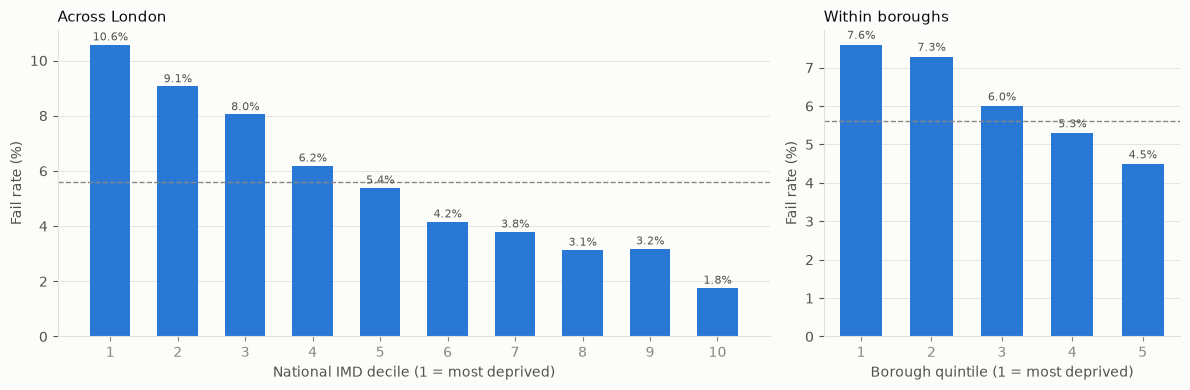

In [7]:
#fail rate by deprivation, across London and within boroughs

import numpy as np

N_LSOAS = 33_755  # LSOAs in England; ranks run from 1 (most deprived) to 33,755

# Only businesses matched to their exact LSOA, so fallback averages don't blur the picture
area = rated[rated["area_match_level"] == "lsoa"].copy()

# National decile: 1 = most deprived 10% of England, 10 = least deprived
area["imd_decile"] = np.ceil(area["imd_rank"] / N_LSOAS * 10).astype(int)

# Within-borough quintile: 1 = most deprived fifth of THAT borough's businesses
area["borough_quintile"] = area.groupby("LocalAuthorityName")["imd_rank"].transform(
    lambda r: pd.qcut(r.rank(method="first"), 5, labels=False) + 1
)

by_decile = area.groupby("imd_decile")["fail"].agg(businesses="size", fail_rate="mean")
by_quintile = area.groupby("borough_quintile")["fail"].agg(businesses="size", fail_rate="mean")

fmt = {"fail_rate": "{:.1%}".format}
print("Across London (national IMD decile, 1 = most deprived):")
print(by_decile.to_string(formatters=fmt))
print("\nWithin boroughs (quintile of the borough's own businesses, 1 = most deprived):")
print(by_quintile.to_string(formatters=fmt))


def plot_ordered(ax, table, title, xlabel):
    """Bars in their natural order (not sorted), with the overall rate marked."""
    ax.bar(table.index.astype(str), table["fail_rate"] * 100, color=BAR, width=0.6)
    ax.axhline(BASE_RATE * 100, color=MUTED, linestyle="--", linewidth=1)
    for x, rate in enumerate(table["fail_rate"]):
        ax.text(x, rate * 100 + 0.15, f"{rate:.1%}", ha="center", fontsize=8)
    ax.set_title(title, loc="left", fontsize=11, color="#0b0b0b")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Fail rate (%)")
    ax.grid(axis="y", color=GRID, linewidth=0.6)
    ax.set_axisbelow(True)


fig, (left, right) = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={"width_ratios": [2, 1]})
plot_ordered(left, by_decile, "Across London", "National IMD decile (1 = most deprived)")
plot_ordered(right, by_quintile, "Within boroughs", "Borough quintile (1 = most deprived)")
plt.tight_layout()
plt.show()

In [8]:
#which area features carry the most signal?

def auc(score, target):
    """Chance that a random failing business scores higher than a random passing one.
    0.5 = no signal, 1.0 = perfect separation."""
    ranks = score.rank()
    n_pos = target.sum()
    n_neg = len(target) - n_pos
    return (ranks[target == 1].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)


RANK_FEATURES = ["imd_rank", "income_rank", "employment_rank", "education_rank",
                 "health_rank", "crime_rank", "housing_barriers_rank", "living_env_rank"]

rows = []
for feature in RANK_FEATURES + ["pop_density"]:
    # For ranks, a LOWER rank means MORE deprived, so flip the sign
    score = -area[feature] if feature in RANK_FEATURES else area[feature]
    london = auc(score, area["fail"])
    within = np.mean([
        auc(score[group.index], group["fail"])
        for _, group in area.groupby("LocalAuthorityName")
    ])
    rows.append({"feature": feature, "london_auc": london, "within_borough_auc": within})

signal = pd.DataFrame(rows).set_index("feature").sort_values("within_borough_auc", ascending=False)
print(signal.round(3).to_string())

                       london_auc  within_borough_auc
feature                                              
imd_rank                    0.617               0.569
income_rank                 0.614               0.567
pop_density                 0.571               0.565
housing_barriers_rank       0.616               0.564
crime_rank                  0.573               0.562
education_rank              0.614               0.560
employment_rank             0.585               0.548
living_env_rank             0.517               0.543
health_rank                 0.554               0.539


## Q3: Deprivation and population density: findings

- **Across London:** fail rate falls steadily from 10.6% (most deprived national
  decile) to 1.8% (least deprived), about 6x.
- **Within boroughs:** the gradient remains and is steady, but much weaker:
  7.6% (most deprived fifth of each borough) to 4.5% (least deprived fifth), about 1.7x.
- **Conclusion:** deprivation is a real effect (it survives controlling for the council),
  but the London-wide view exaggerates it, because the strictest councils are also
  deprived. Checking within boroughs was necessary to avoid overstating it.
- Deciles 9 and 10 are small (inner London has few of England's least deprived areas),
  so their exact rates are less reliable.

### Single-feature signal (AUC, 0.5 = no signal)
- All area features score **0.54 to 0.57 within boroughs**: modest on their own.
- The deprivation domains are highly correlated with each other. Fine for tree-model
  predictions, but SHAP credit will be split among them, so explain them as a group
  ("area deprivation"), not individually.
- **Population density** barely changed after removing the council effect (0.571 to 0.565),
  so its signal is not tangled with council strictness.
- **Living environment** *rose* within boroughs (0.517 to 0.543): central boroughs have
  poor living environment but lenient ratings, which hid its effect London-wide.
  Confounding can work in both directions.

### Fairness note
A model using deprivation will send inspectors more often to poorer neighbourhoods.
The data supports a higher failure rate there, but ratings come from human inspectors,
so any scoring bias would be learned and amplified. To be measured in the fairness step.

Question 4 :- Is address_withheld just business type in disguise?

In [9]:
# 1. Fail rate for listed vs withheld addresses, within each business type
split = (
    rated.groupby(["BusinessType", "address_withheld"])["fail"]
    .agg(businesses="size", fail_rate="mean")
    .unstack("address_withheld")
)
split.columns = ["n_listed", "n_withheld", "rate_listed", "rate_withheld"]
split["share_withheld"] = split["n_withheld"] / (split["n_listed"] + split["n_withheld"])
split = split.sort_values("n_withheld", ascending=False)

pct = "{:.1%}".format
print("Listed vs withheld address, by business type:")
print(split.to_string(formatters={
    "n_listed": "{:,.0f}".format, "n_withheld": "{:,.0f}".format,
    "rate_listed": pct, "rate_withheld": pct, "share_withheld": pct,
}))

# 2. Does withheld still fail less after adjusting for business type?
check = rated[["BusinessType", "address_withheld", "fail"]].copy()
check["expected"] = check.groupby("BusinessType")["fail"].transform("mean")
adjusted = check.groupby("address_withheld").agg(
    businesses=("fail", "size"), actual=("fail", "mean"), expected=("expected", "mean")
)
adjusted["ratio"] = adjusted["actual"] / adjusted["expected"]
adjusted.index = ["listed address", "withheld address"]
print("\nAdjusted for business type:")
print(adjusted.to_string(formatters={"actual": pct, "expected": pct, "ratio": "{:.2f}".format}))

Listed vs withheld address, by business type:
                                      n_listed n_withheld rate_listed rate_withheld share_withheld
BusinessType                                                                                      
Other catering premises                  2,708      3,392        3.5%          1.2%          55.6%
Mobile caterer                             759      1,190        5.3%          1.9%          61.1%
Restaurant/Cafe/Canteen                 24,179      1,109        6.2%          1.0%           4.4%
Retailers - other                       12,718        868        9.6%          2.3%           6.4%
Takeaway/sandwich shop                   8,287        278        8.0%          2.2%           3.2%
Caring Premises                          4,107        218        1.9%          0.9%           5.0%
Manufacturers/packers                      643        213        6.8%          0.0%          24.9%
Distributors/Transporters                  360         73      

## Q4: Is address_withheld just business type in disguise? Findings

- **Partly business mix:** withheld addresses are concentrated in low-risk types.
  Other catering premises (3,392) and Mobile caterer (1,190) make up 61% of all
  withheld addresses. From business type alone, withheld businesses would be
  expected to fail at 4.0% (vs 5.8% for listed).
- **But mostly independent of type:** withheld businesses actually fail at **1.5%**,
  a ratio of **0.36** vs expected. They fail about a third as often as similar
  businesses with a listed address.
- **Consistent within every large type** (listed vs withheld): Retailers - other
  9.6% vs 2.3%, Takeaway 8.0% vs 2.2%, Restaurant 6.2% vs 1.0%, Mobile caterer
  5.3% vs 1.9%, Other catering 3.5% vs 1.2%. The reversed small groups
  (Distributors n=73, Pubs n=39) are noise.
- **Likely explanation:** a withheld address marks a small, home-based operation
  (home kitchen, online food business), which the business type label does not capture.
- **Decision:** keep `address_withheld` as a feature.
- **Caution:** the flag may partly reflect council recording habits (Ealing and
  Enfield record withheld addresses at sector level). Handled by keeping borough as a
  feature and ranking within boroughs.

Question 5: Chains vs independents

In [10]:
# normalise names and count locations

LEGAL_WORDS = r"\b(LTD|LIMITED|PLC|LLP|UK|THE)\b"


def normalise_name(names):
    """Uppercase, '&' -> AND, drop punctuation and legal words, squash spaces."""
    return (
        names.fillna("").str.upper()
        .str.replace("'", "", regex=False)
        .str.replace("&", " AND ", regex=False)
        .str.replace(r"[^A-Z0-9 ]", " ", regex=True)
        .str.replace(LEGAL_WORDS, " ", regex=True)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )


# Count locations across ALL businesses (rated or not): chain size doesn't depend on ratings
df["name_clean"] = normalise_name(df["BusinessName"])
df["name_count"] = df.groupby("name_clean")["name_clean"].transform("size")
df.loc[df["name_clean"] == "", "name_count"] = 1

print("Most common names in London:")
print(df["name_clean"].value_counts().head(40).to_string())

Most common names in London:
name_clean
TESCO                         326
SAINSBURYS                    303
PRET A MANGER                 259
COSTA COFFEE                  222
SUBWAY                        205
GREGGS                        195
DOMINOS PIZZA                 145
MCDONALDS                     139
CAFFE NERO                    132
TESCO EXPRESS                 126
LONDIS                        123
BOOTS                         122
KFC                           119
HOLLAND AND BARRETT           113
NANDOS                        111
LIDL                          101
STARBUCKS                      97
COSTA                          96
CO OP                          91
NISA LOCAL                     82
COSTCUTTER                     79
WAITROSE                       75
ICELAND                        72
PIZZA EXPRESS                  72
STARBUCKS COFFEE COMPANY       69
MARKS AND SPENCER              62
POUNDLAND                      60
OLIVE DINING                   58
JOE AND 

                   businesses fail_rate expected ratio
chain_band                                            
Independent (1)         51842      6.2%     5.5%  1.14
Small group (2-4)        8844      5.8%     5.9%  0.98
Chain (5+)              10704      2.4%     5.9%  0.41


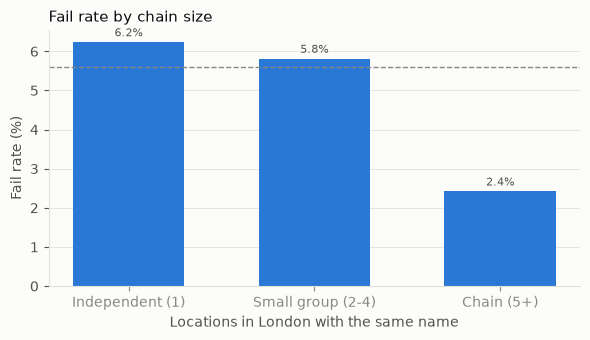

In [11]:
# fail rate by chain size, adjusted for business type

bins = [0, 1, 4, float("inf")]
labels = ["Independent (1)", "Small group (2-4)", "Chain (5+)"]
df["chain_band"] = pd.cut(df["name_count"], bins=bins, labels=labels)

# Copy the new columns onto the rated businesses (same row index)
rated["name_count"] = df["name_count"]
rated["chain_band"] = df["chain_band"]

check = rated[["BusinessType", "chain_band", "fail"]].copy()
check["expected"] = check.groupby("BusinessType")["fail"].transform("mean")
by_band = check.groupby("chain_band", observed=True).agg(
    businesses=("fail", "size"), fail_rate=("fail", "mean"), expected=("expected", "mean")
)
by_band["ratio"] = by_band["fail_rate"] / by_band["expected"]
print(by_band.to_string(formatters={
    "fail_rate": pct, "expected": pct, "ratio": "{:.2f}".format,
}))

fig, ax = plt.subplots(figsize=(6, 3.5))
plot_ordered(ax, by_band, "Fail rate by chain size", "Locations in London with the same name")
plt.tight_layout()
plt.show()

## Q5: Chains vs independents: findings

- **Feature built from BusinessName:** uppercase, remove apostrophes, "&" to "AND",
  strip punctuation and legal words (LTD, LIMITED, PLC, LLP, UK, THE), then count
  locations sharing each cleaned name across ALL London businesses (no ratings used).
- **Detection works:** the 40 most common names are all real chains (Tesco, Sainsbury's,
  Pret, Costa, Subway, Greggs, McDonald's...). Includes contract caterers (Olive Dining,
  Harrison Catering) that are chains despite no high-street presence.
- **Known split brands** (TESCO / TESCO EXPRESS, COSTA / COSTA COFFEE, BOOTS / BOOTS
  CHEMIST...). No effect on the chain band since each part has 5+ locations.
- **Results (ratio = actual / expected from business type):**
  - Independent (1): 6.2%, ratio 1.14
  - Small group (2-4): 5.8%, ratio 0.98
  - **Chain (5+): 2.4%, ratio 0.41**, under half the rate their type predicts
- **Interpretation:** the benefit appears only at real chain scale (head-office
  procedures, training, audits, brand reputation). Small groups behave like independents.
- **Decision:** add `name_count` as a feature.
- **Limitations:** national chains with few London outlets look like small groups;
  franchises and company-run chains are not distinguished.